In [34]:
import pandas as pd
import csv
df = pd.read_csv("Titanic-Dataset.csv")
print(df.shape)
print(df.head())


(891, 12)
   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         0       3  ...   7.2500   NaN         S
1            2         1       1  ...  71.2833   C85         C
2            3         1       3  ...   7.9250   NaN         S
3            4         1       1  ...  53.1000  C123         S
4            5         0       3  ...   8.0500   NaN         S

[5 rows x 12 columns]


In [35]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['Embarked'].value_counts())

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [36]:
df = df.drop(labels = 'Cabin',axis = 1)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna('S')

In [37]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [38]:
df = df.drop(labels = ['PassengerId','Name','Ticket'],axis = 1)

In [39]:
df['Sex'] = df['Sex'].map({'male':1,'female':0})
df = pd.get_dummies(df,columns=['Embarked'])
print(df.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [40]:
print(df.duplicated().sum())

116


In [41]:
df = df.drop_duplicates()
df.shape

(775, 10)

In [42]:
df.groupby('Survived')['Age'].mean()

Survived
0    30.482418
1    28.299750
Name: Age, dtype: float64

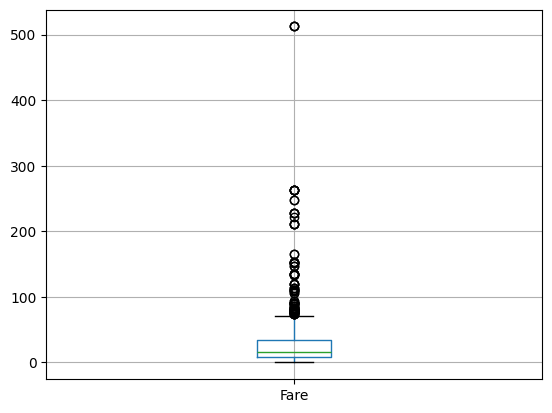

In [43]:
import matplotlib.pyplot as plt
df.boxplot(column=['Fare'])
plt.show()

In [44]:
df.dtypes

Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_C       bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

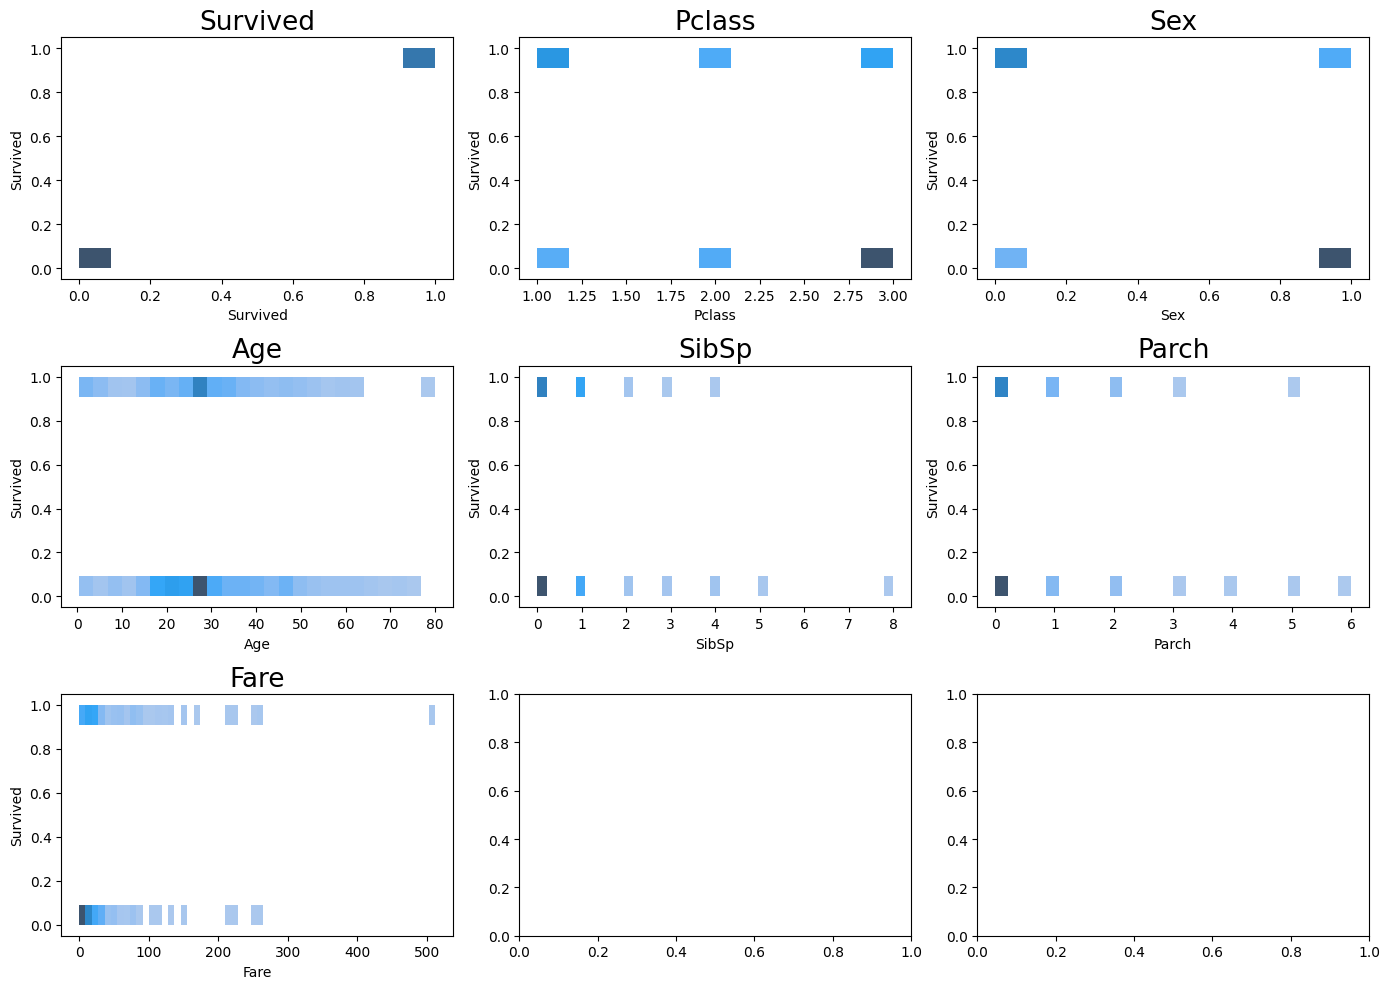

In [45]:
import seaborn as sns
cols = df.select_dtypes(include=['int64','float64'])
fig , axes = plt.subplots(3,3,figsize = (14,10))
axes = axes.flatten()
for i ,col in enumerate(cols):
    sns.histplot(data=df,x = col,y = 'Survived',kde = True,ax = axes[i])
    axes[i].set_title(col,fontsize = 19)
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

In [46]:
y = df['Survived']
x = df.drop(labels = 'Survived' , axis = 1)

In [47]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [48]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
x_train_scaled = scale.fit_transform(x_train)
x_test_scaled = scale.transform(x_test)


In [49]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression()
model1.fit(x_train_scaled,y_train)
y_pred = model1.predict(x_test_scaled)
from sklearn.metrics import accuracy_score
y_train_pred = model1.predict(x_train_scaled)
print(f"training = {accuracy_score(y_train,y_train_pred):.2f}")
print(f"test = {accuracy_score(y_test,y_pred):.2f}")
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

training = 0.78
test = 0.78
[[115  27]
 [ 25  66]]


In [50]:
from sklearn.tree import DecisionTreeClassifier
model2 = DecisionTreeClassifier(max_depth= 3 , random_state= 36)
model2.fit(x_train,y_train)
y_pred = model2.predict(x_test)
y_train_pred = model2.predict(x_train)
print(f"training  {accuracy_score(y_train,y_train_pred):.2f}")
print(f"testing  {accuracy_score(y_test,y_pred):.2f}")
print(confusion_matrix(y_test, y_pred))

training  0.82
testing  0.80
[[138   4]
 [ 42  49]]


In [51]:
from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier(max_depth = 4,random_state=36,n_estimators=100)
model3.fit(x_train,y_train)
y_train_pred = model3.predict(x_train)
y_pred = model3.predict(x_test)
print(f"training  {accuracy_score(y_train,y_train_pred):.2f}")
print(f"testing  {accuracy_score(y_test,y_pred):.2f}")
print(confusion_matrix(y_test, y_pred))

training  0.83
testing  0.81
[[134   8]
 [ 37  54]]


In [ ]:
from sklearn.ensemble import BaggingClassifier
model4 = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=3),n_estimators=100,random_state=36)
model4.fit(x_train,y_train)
y_train_pred = model4.predict(x_train)
y_pred = model4.predict(x_test)
print(f"training  {accuracy_score(y_train,y_train_pred):.2f}")
print(f"testing  {accuracy_score(y_test,y_pred):.2f}")
print(confusion_matrix(y_test, y_pred))

training  0.82
testing  0.80
[[137   5]
 [ 42  49]]


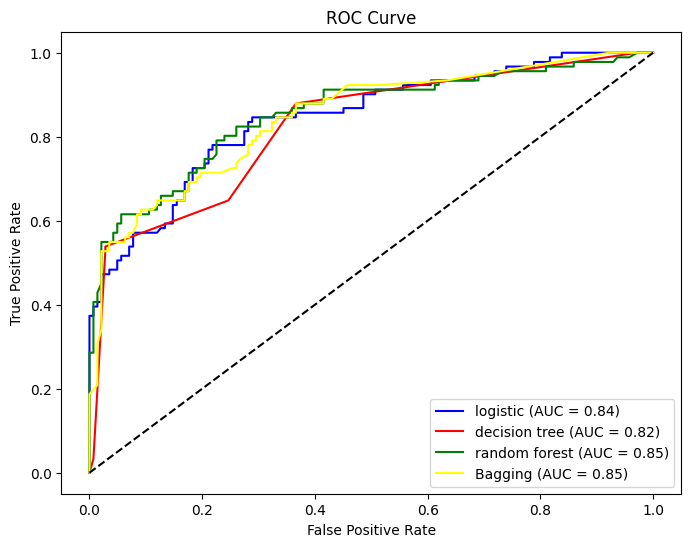

In [61]:
from sklearn.metrics import roc_auc_score,roc_curve,auc
plt.figure(figsize=(8,6))
#logistic
fpr, tpr, _ = roc_curve(y_test, model1.predict_proba(x_test_scaled)[:,1])
auc_score = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'logistic (AUC = {auc_score:.2f})',color = 'blue')
#decision tree
fpr, tpr, _ = roc_curve(y_test, model2.predict_proba(x_test)[:,1])
auc_score = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'decision tree (AUC = {auc_score:.2f})',color = 'red')
#random forest
fpr, tpr, _ = roc_curve(y_test, model3.predict_proba(x_test)[:,1])
auc_score = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'random forest (AUC = {auc_score:.2f})',color = 'green')
#Bagging of decision tree
fpr, tpr, _ = roc_curve(y_test, model4.predict_proba(x_test)[:,1])
auc_score = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'Bagging (AUC = {auc_score:.2f})',color = 'yellow')

plt.plot([0,1],[0,1],'k--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [65]:
import pickle
with open('model.pkl','wb') as fh:
    pickle.dump(model1,fh)
with open('scale.pkl','wb') as fh:
    pickle.dump(scale,fh)


In [67]:
with open('scale.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)


new_input_scaled = loaded_scaler.transform(x_test)

# Predict
prediction = loaded_model.predict(new_input_scaled)
print(accuracy_score(y_test,prediction))

0.776824034334764


In [72]:
print(x.columns)
df

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,False,True
1,1,1,0,38.0,1,0,71.2833,True,False,False
2,1,3,0,26.0,0,0,7.9250,False,False,True
3,1,1,0,35.0,1,0,53.1000,False,False,True
4,0,3,1,35.0,0,0,8.0500,False,False,True
...,...,...,...,...,...,...,...,...,...,...
885,0,3,0,39.0,0,5,29.1250,False,True,False
887,1,1,0,19.0,0,0,30.0000,False,False,True
888,0,3,0,28.0,1,2,23.4500,False,False,True
889,1,1,1,26.0,0,0,30.0000,True,False,False
